# Solução homogeneizada

## Coeficientes efetivos

$
\hat{C}_{11} = \left( C_{11}(y)^{-1} \right)^{-1}
= \frac{1}{\left( \frac{1}{C_{11}(y)} \right)}
= \frac{1}{\left( \frac{v_1}{C_{11}^{(1)}} + \frac{v_2}{C_{11}^{(2)}} \right)}
= \frac{C_{11}^{(1)}\, C_{11}^{(2)}}{C_{11}^{(2)} v_1 + C_{11}^{(1)} v_2}.
$


$
\hat{C}_{12}
= \left( C_{11}(y)^{-1} \right)^{-1}
\left( \frac{C_{11}(y)}{C_{12}(y)} \right)
= \hat{C}_{11}
\left(
\frac{C_{12}^{(1)}}{C_{11}^{(1)}} v_1
+
\frac{C_{12}^{(2)}}{C_{11}^{(2)}} v_2
\right).
$



## Solução analítica via scipy

<>:124: SyntaxWarning: invalid escape sequence '\m'
<>:124: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8495/3795567872.py:124: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('Deslocamento ($\mu m$)')


Coeficientes Efetivos
C11_hat: 14.65 MPa,
C12_hat: 6.77
Constantes encontradas: A=-1.41225483047758E-7, B=-0.0000310980193260653


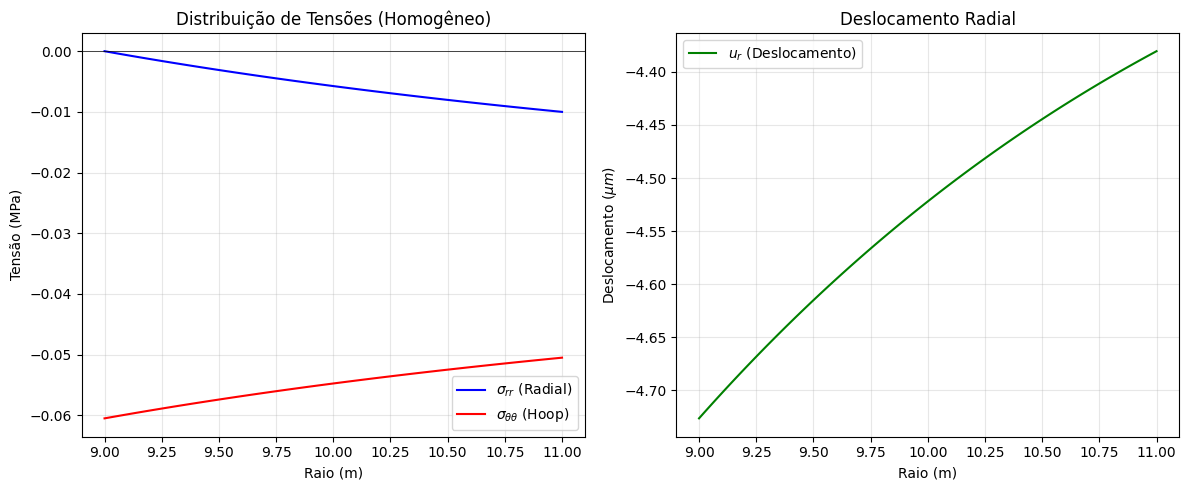

In [ ]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_bvp
from scipy.integrate import quad

def effective_coeffs(E_1, E_2, nu_1, nu_2, v1, v2):

  lmbda_1 = (E_1 * nu_1) / ((1 + nu_1) * (1 - 2 * nu_1))
  lmbda_2 = (E_2 * nu_2) / ((1 + nu_2) * (1 - 2 * nu_2))

  mu_1 = E_1 / (2 * (1 + nu_1))
  mu_2 = E_2 / (2 * (1 + nu_2))

  # C11_1 = E_1 / (1 - nu_1**2)
  # C11_2 = E_2 / (1 - nu_2**2)

  # C12_1 = E_1 / (2 * (1 + nu_1))
  # C12_2 = E_2 / (2 * (1 + nu_2))

  C11_1 = lmbda_1 + 2*mu_1
  C11_2 = lmbda_2 + 2*mu_2

  C12_1 = lmbda_1
  C12_2 = lmbda_2

  C11_hat = 1 / ((v1 / C11_1) +  (v2 / C11_2))
  C12_hat = C11_hat * ((C12_1 / C11_1) * v1 + (C12_2 / C11_2) * v2)
  # C12_hat = C12_1 * v1 + C12_2 * v2

  # C11_hat = C11 / (1 + nu)
  # C12_hat = C12 / (1 - 2 * nu)

  return C11_hat, C12_hat

def solve_homogeneous_cylinder():
    # 1. Variáveis Simbólicas
    r = sp.symbols('r')
    A, B = sp.symbols('A B') # Apenas duas constantes agora

    # 2. Parâmetros Físicos (Apenas um material)
    R_int = 9.0 # mm
    R_ext = 11.0 # mm
    R_I = R_int + (R_ext - R_int)/2

    # Camada dupla (Ex: Aço e Alumínio)
    E1, nu1 = 200e9, 0.30  # Material 1 (Aço)
    E2, nu2 = 70e9,  0.33  # Material 2 (Alumínio)

    # Cargas
    P_int_val = 0.0 # MPa
    P_ext_val = 10e3   # 10 MPa = 10 N/mm^2

    # 3. Equações Constitutivas (Lei de Hooke em Cilíndricas)
    # Constantes de Lamé
    # lmbda = (E_val * nu_val) / ((1 + nu_val) * (1 - 2 * nu_val))
    # mu = E_val / (2 * (1 + nu_val))

    # 3. Cálculo dos coeficientes efetivos
    # 3.1 Frações volumétricas

    v1 = np.pi * (R_I**2 - R_int**2) / (np.pi * (R_ext**2 - R_int**2))
    v2 = 1 - v1

    C11_hat, C12_hat = effective_coeffs(E1, E2, nu1, nu2, v1, v2)
    print('Coeficientes Efetivos')
    print(f'C11_hat: {C11_hat / 10e9:.2f} MPa,\nC12_hat: {C12_hat / 10e9:.2f}')

    # Deformações (Kinematics)
    # u = A*r + B/r

    eps_rr = A - B/(r**2)
    eps_tt = A + B/(r**2)

    # Tensões (Constitutive)
    # sig_rr = lmbda*(eps_rr + eps_tt) + 2*mu*eps_rr
    # sig_tt = lmbda*(eps_rr + eps_tt) + 2*mu*eps_tt

    sig_rr = C11_hat*eps_rr + C12_hat*eps_tt
    sig_tt = C12_hat*eps_rr + C11_hat*eps_tt
    u_r = A*r + B/r

    # 4. Sistema de Equações (Condições de Contorno)
    equations = []

    # BC 1: Pressão na parede interna
    # sigma_rr(R_int) = -P_int
    eq_in = sp.Eq(sig_rr.subs(r, R_int), -P_int_val)
    equations.append(eq_in)

    # BC 2: Pressão na parede externa
    # sigma_rr(R_ext) = -P_ext
    eq_out = sp.Eq(sig_rr.subs(r, R_ext), -P_ext_val)
    equations.append(eq_out)

    # 5. Solução
    sol = sp.solve(equations, (A, B))
    print(f"Constantes encontradas: A={sol[A]}, B={sol[B]}")

    # 6. Preparar para Plotagem
    func_srr = sp.lambdify(r, sig_rr.subs(sol), 'numpy')
    func_stt = sp.lambdify(r, sig_tt.subs(sol), 'numpy')
    func_u   = sp.lambdify(r, u_r.subs(sol), 'numpy')

    # Domínio radial
    radii = np.linspace(R_int, R_ext, 100)

    # --- Plotagem ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico 1: Tensões
    ax1.plot(radii, func_srr(radii)/1e6, 'b-', label=r'$\sigma_{rr}$ (Radial)')
    ax1.plot(radii, func_stt(radii)/1e6, 'r-', label=r'$\sigma_{\theta\theta}$ (Hoop)')
    ax1.set_xlabel('Raio (m)')
    ax1.set_ylabel('Tensão (MPa)')
    ax1.set_title('Distribuição de Tensões (Homogêneo)')
    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Gráfico 2: Deslocamento
    ax2.plot(radii, func_u(radii)*1e6, 'g-', label=r'$u_r$ (Deslocamento)')
    ax2.set_xlabel('Raio (m)')
    ax2.set_ylabel('Deslocamento ($\mu m$)')
    ax2.set_title('Deslocamento Radial')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('cilindro_homogeneo.png') # Salva para exibir depois
    plt.show()

    return func_u

if __name__ == "__main__":
    u_MHA = solve_homogeneous_cylinder()

## Código corrigido

Coeficientes Efetivos (Pa):
C11: 1.46e+11
C12: 6.77e+10
C22: 1.77e+11
Fator de Anisotropia k: 1.0990


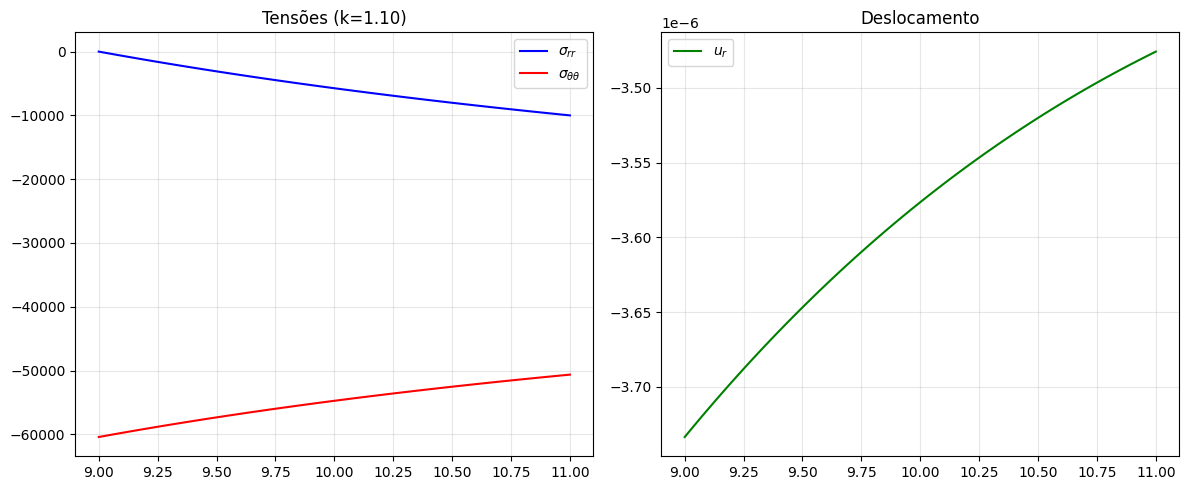

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def effective_coeffs(E_1, E_2, nu_1, nu_2, v1, v2):
    # Parâmetros de Lamé e Matriz de Rigidez Local (Isotrópica em cada fase)
    lmbda_1 = (E_1 * nu_1) / ((1 + nu_1) * (1 - 2 * nu_1))
    mu_1 = E_1 / (2 * (1 + nu_1))
    C11_1 = lmbda_1 + 2*mu_1
    C12_1 = lmbda_1
    C22_1 = C11_1 # Isotrópico localmente

    lmbda_2 = (E_2 * nu_2) / ((1 + nu_2) * (1 - 2 * nu_2))
    mu_2 = E_2 / (2 * (1 + nu_2))
    C11_2 = lmbda_2 + 2*mu_2
    C12_2 = lmbda_2
    C22_2 = C11_2 # Isotrópico localmente

    # --- Homogeneização Assintótica ---

    # 1. C11 efetivo (Média Harmônica - Série)
    C11_hat = 1 / ( (v1 / C11_1) +  (v2 / C11_2) )

    # 2. C12 efetivo (Conforme discutido anteriormente)
    # C12_hat = C11_hat * < C12 / C11 >

    C12_hat = C11_hat * ( (C12_1 / C11_1 * v1) + (C12_2 / C11_2 * v2) )

    # 3. C22 efetivo (Complexo - envolve termo de acoplamento)
    # Fórmula: < C22 - C12^2/C11 > + C12_hat^2 / C11_hat
    term_1 = (C22_1 - (C12_1**2)/C11_1) * v1
    term_2 = (C22_2 - (C12_2**2)/C11_2) * v2
    avg_reduced = term_1 + term_2

    C22_hat = avg_reduced + (C12_hat**2)/C11_hat

    return C11_hat, C12_hat, C22_hat

def solve_homogeneous_cylinder():
    r = sp.symbols('r')
    A, B = sp.symbols('A B')

    # Geometria e Materiais
    R_int, R_ext = 9.0, 11.0
    R_I = 9 + (R_ext - R_int)/2
    E1, nu1 = 200e9, 0.30
    E2, nu2 = 70e9, 0.33
    P_int_val, P_ext_val = 0.0, 10e3

    # 1. CORREÇÃO: Fração Volumétrica (Sinal de menos no denominador)
    area_total = np.pi * (R_ext**2 - R_int**2)
    v1 = (np.pi * (R_I**2 - R_int**2)) / area_total
    v2 = 1 - v1

    # 2. CORREÇÃO: Obter C22 também
    C11_hat, C12_hat, C22_hat = effective_coeffs(E1, E2, nu1, nu2, v1, v2)

    print(f'Coeficientes Efetivos (Pa):\nC11: {C11_hat:.2e}\nC12: {C12_hat:.2e}\nC22: {C22_hat:.2e}')

    # 3. CORREÇÃO: Solução da EDO para material ortotrópico
    # k mede o grau de anisotropia (k=1 é isotrópico)
    k_val = np.sqrt(C22_hat / C11_hat)
    print(f'Fator de Anisotropia k: {k_val:.4f}')

    # Solução Geral: u = A*r^k + B*r^-k
    u_r = A * r**k_val + B * r**(-k_val)

    # Deformações (Derivadas)
    eps_rr = sp.diff(u_r, r) # du/dr
    eps_tt = u_r / r         # u/r

    # Lei de Hooke (Ortotrópica)
    sig_rr = C11_hat * eps_rr + C12_hat * eps_tt
    sig_tt = C12_hat * eps_rr + C22_hat * eps_tt # Usa C22 aqui!

    # Condições de Contorno e Solução
    equations = [
        sp.Eq(sig_rr.subs(r, R_int), -P_int_val),
        sp.Eq(sig_rr.subs(r, R_ext), -P_ext_val)
    ]

    sol = sp.solve(equations, (A, B))

    # Plotagem (igual ao seu código)
    func_srr = sp.lambdify(r, sig_rr.subs(sol), 'numpy')
    func_stt = sp.lambdify(r, sig_tt.subs(sol), 'numpy')
    func_u   = sp.lambdify(r, u_r.subs(sol), 'numpy')

    radii = np.linspace(R_int, R_ext, 100)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(radii, func_srr(radii), 'b-', label=r'$\sigma_{rr}$')
    ax1.plot(radii, func_stt(radii), 'r-', label=r'$\sigma_{\theta\theta}$')
    ax1.set_title(f'Tensões (k={k_val:.2f})')
    ax1.grid(True, alpha=0.3); ax1.legend()

    ax2.plot(radii, func_u(radii), 'g-', label=r'$u_r$')
    ax2.set_title('Deslocamento')
    ax2.grid(True, alpha=0.3); ax2.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    solve_homogeneous_cylinder()

# Axisymmetric formulation for elastic structures of revolution

In this numerical tour, we will deal with axisymmetric problems of elastic solids. We will consider a solid of revolution around a fixed axis $(Oz)$, the loading, boundary conditions and material properties being also invariant with respect to a rotation along the symmetry axis. The solid cross-section in a plane $\theta=\text{cst}$ will be represented by a two-dimensional domain $\omega$ for which the first spatial variable (`x[0]` in FEniCS) will represent the radial coordinate $r$ whereas the second spatial variable will denote the axial variable $z$.

## Problem position

We will investigate here the case of a hollow hemisphere of inner (resp. outer) radius $R_i$ (resp. $R_e$). Due to the revolution symmetry, the 2D cross-section corresponds to a quarter of a hollow cylinder.

In [1]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

--2026-03-16 19:48:08--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-03-16 19:48:08 (85.0 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/7e396ce3/releases/pybi

In [2]:
from __future__ import print_function
from dolfin import *
from mshr import *
import matplotlib.pyplot as plt
%matplotlib inline

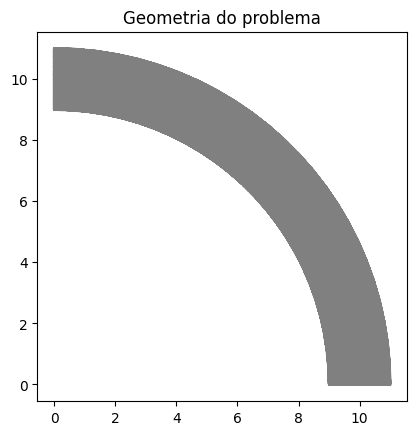

In [ ]:
# --- DADOS DO PROBLEMA ---
Re = 11. # Raio externo
Ri = 9. # Raio interno
E1, nu1 = 200e9, 0.30  # Material 1 (Aço)
E2, nu2 = 70e9,  0.33  # Material 2 (Alumínio)

# --- Número de camadas ---
n_layers = 20

# --- N° de elementos ---
elems = 300 # Qual é a relação entre o n° de camadas e o número ideal de elementos?

# --- Pressão externa ---
p = Constant(10e3)

# --- CRIAÇÃO DA GEOMETRIA ---

rect = Rectangle(Point(0., 0.), Point(Re, Re))
#domain = Circle(Point(0., 0.), Re, 100) - Circle(Point(0., 0.), Ri, 100)
#domain = domain - Rectangle(Point(0., -Re), Point(-Re, Re)) \
#                - Rectangle(Point(0., 0.), Point(Re, -Re)) # Simulando 1/4 do domínio

def get_domain(Re:float, consider_symmetry:bool=False):
  domain = Circle(Point(0., 0.), Re, 100) - Circle(Point(0., 0.), Ri, 100)
  if consider_symmetry:
    return domain - Rectangle(Point(0., -Re), Point(-Re, Re)) \
                    - Rectangle(Point(0., 0.), Point(Re, -Re)) # Simulando 1/4 do domínio
  else:
    return domain


domain = get_domain(Re, consider_symmetry=True)

mesh = generate_mesh(domain, elems)
plot(mesh)
plt.title('Geometria do problema')
plt.show() # Added plt.show()

# Classes para definição das superfícies
class Bottom(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0) and on_boundary
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0) and on_boundary
class Outer(SubDomain):
    def inside(self, x, on_boundary):
        return near(sqrt(x[0]**2+x[1]**2), Re, 1e-1) and on_boundary # O termo sqrt(x[0]**2+x[1]**2) faz sentido apenas se x[0] → x, x[1] → y

facets = MeshFunction("size_t", mesh, 1)
facets.set_all(0)
Bottom().mark(facets, 1)
Left().mark(facets, 2)
Outer().mark(facets, 3)
ds = Measure("ds", subdomain_data=facets)

## Definition of axisymmetric strains

For axisymmetric conditions, the unkown displacement field is of the form:

$$\begin{equation}
\boldsymbol{u} = u_r(r,z)\boldsymbol{e}_r + u_z(r,z)\boldsymbol{e}_z
\end{equation}$$

As a result, we will work with a standard VectorFunctionSpace of dimension 2. The associated strain components are however given by:

$$\begin{equation}
\boldsymbol{\varepsilon} = \begin{bmatrix} \partial_r u_r & 0 & (\partial_z u_r + \partial_r u_z)/2 \\
0 & u_r/r & 0 \\
(\partial_z u_r + \partial_r u_z)/2 & 0 & \partial_z u_z\end{bmatrix}_{(\boldsymbol{e}_r,\boldsymbol{e}_\theta,\boldsymbol{e}_z)}
\end{equation}$$

The previous relation involves explicitly the radial variable $r$, which can be obtained from the SpatialCoordinate `x[0]`, the strain-displacement relation is then defined explicitly in the `eps` function.

> **Note**: we could also express the strain components in the form of a vector of size 4 in alternative of the 3D tensor representation implemented below.

## Elastic properties of the layers and interface position

In [ ]:
from dolfin import UserExpression

# Lista de interfaces (raios onde a troca acontece)
# A lógica será:
# r <= 10.00: Material 1 (Núcleo)
# 10.00 < r <= 10.25: Material 2
# 10.25 < r <= 10.50: Material 1
# 10.50 < r <= 10.75: Material 2
# r > 10.75: Material 1 (Resto do domínio)

R_interfaces = [Ri + i*(Re - Ri)/n_layers for i in range(n_layers)][1:]

degree = 0

# --- CLASSE GENÉRICA PARA CAMADAS ESFÉRICAS? ---
class PropriedadePeriodica(UserExpression):
    def __init__(self, val1, val2, interfaces, **kwargs):
        super().__init__(**kwargs)
        self.val1 = val1
        self.val2 = val2
        # Otimização: Guarda o quadrado dos raios e garante ordem
        self.R_sq = sorted([r**2 for r in interfaces])

    def eval(self, values, x):
        # Geometria Cilíndrica
        r_sq = x[0]**2 + x[1]**2

        # Descobre o índice da camada
        idx = 0
        found = False
        for i, raio_sq in enumerate(self.R_sq):
            if r_sq <= raio_sq:
                idx = i
                found = True
                break

        if not found:
            idx = len(self.R_sq) # Está além da última interface

        # Lógica de alternância (Par/Ímpar)
        # idx 0 (Núcleo) -> val1
        # idx 1 -> val2
        # idx 2 -> val1 ...
        if idx % 2 == 0:
            values[0] = self.val1
        else:
            values[0] = self.val2

    def value_shape(self):
        return ()

# --- INSTANCIAÇÃO CORRETA ---

# Note que usamos a mesma classe, passando os valores correspondentes
# Ambos recebem a lista COMPLETA 'R_interfaces'

print("Criando expressão para Módulo de Young (E)...")
E_func = PropriedadePeriodica(E1, E2, R_interfaces, degree=degree)

print("Criando expressão para Coef. de Poisson (nu)...")
nu_func = PropriedadePeriodica(nu1, nu2, R_interfaces, degree=degree)

# --- FÓRMULAS DE LAMÉ ---
# O FEniCS vai combinar as duas expressões alternadas automaticamente aqui
lambda_func = (E_func * nu_func) / ((1.0 + nu_func) * (1.0 - 2.0 * nu_func))
mu_func = E_func / (2.0 * (1.0 + nu_func))

# print("Expressões prontas.")

x = SpatialCoordinate(mesh)

def eps(v):
    return sym(as_tensor([[v[0].dx(0), 0, v[0].dx(1)],
                          [0, v[0]/x[0], 0],
                          [v[1].dx(0), 0, v[1].dx(1)]]))
# E = Constant(1e5)
# nu = Constant(0.3)
# mu = E/2/(1+nu)
# lmbda = E*nu/(1+nu)/(1-2*nu)

def sigma(v):
    return lambda_func*tr(eps(v))*Identity(3) + 2.0*mu_func*eps(v)

# 1. Definir um espaço para as propriedades do material
# Usamos "DG" (Discontinuous Galerkin) de grau 0.
# Isso significa que o valor é constante dentro de cada elemento da malha.
V_prop = FunctionSpace(mesh, "DG", 0)

# 2. Projetar (ou interpolar) sua Expressão nesse espaço
# 'project' é mais robusto, 'interpolate' é mais rápido.
# Vamos usar 'project' para E e 'interpolate' para nu (apenas para exemplo).

print("Projetando Módulo de Young (E)...")
E_viz = project(E_func, V_prop)
E_viz.rename("Modulo_Young", "E") # Nome que aparecerá no Paraview

print("Interpolando Coeficiente de Poisson (nu)...")
nu_viz = interpolate(nu_func, V_prop)
nu_viz.rename("Coef_Poisson", "nu")

print("Projetando Módulo de Young (E)...")
lambda_viz = project(lambda_func, V_prop)
lambda_viz.rename("Modulo_Young", "E") # Nome que aparecerá no Paraview

print("Projetando Módulo de Young (E)...")
mu_viz = project(mu_func, V_prop)
mu_viz.rename("Modulo_Young", "E") # Nome que aparecerá no Paraview

# 3. Salvar os campos em um arquivo .pvd para Paraview
print("Salvando arquivos de visualização de propriedades...")
vtkfile_E = File("verificacao/E_field.pvd")
vtkfile_E << E_viz

vtkfile_nu = File("verificacao/nu_field.pvd")
vtkfile_nu << nu_viz

print("Verificação salva. Abra os arquivos .pvd na pasta 'verificacao' com o Paraview.")

Criando expressão para Módulo de Young (E)...
Criando expressão para Coef. de Poisson (nu)...
Projetando Módulo de Young (E)...
Interpolando Coeficiente de Poisson (nu)...
Projetando Módulo de Young (E)...
Projetando Módulo de Young (E)...
Salvando arquivos de visualização de propriedades...
Verificação salva. Abra os arquivos .pvd na pasta 'verificacao' com o Paraview.


## Resolution

The rest of the formulation is similar to the 2D elastic case with a small difference in the integration measure. Indeed, the virtual work principle reads as:

$$\begin{equation}
 \text{Find } \boldsymbol{u}\in V \text{ s.t. } \int_{\Omega}
 \boldsymbol{\sigma}(\boldsymbol{u}):\boldsymbol{\varepsilon}(\boldsymbol{v}) d\Omega
 = \int_{\partial \Omega_T} \boldsymbol{T}\cdot\boldsymbol{v}  dS \quad \forall\boldsymbol{v} \in V
 \end{equation}$$

where $\boldsymbol{T}$ is the imposed traction on some part $\partial \Omega_T$ of the domain boundary.

In axisymmetric conditions, the full 3D domain $\Omega$ can be decomposed as $\Omega = \omega \times [0;2\pi]$ where the interval represents the $\theta$ variable. The integration measures therefore reduce to $d\Omega = d\omega\cdot(rd\theta)$ and $dS = ds\cdot(rd\theta)$ where $dS$ is the surface integration measure on the 3D domain $\Omega$ and $ds$ its counterpart on the cross-section boundary $\partial \omega$. Exploiting the invariance of all fields with respect to $\theta$, the previous virtual work principle is reformulated on the cross-section only as follows:

$$\begin{equation}
 \text{Find } \boldsymbol{u}\in V \text{ s.t. } \int_{\omega}
 \boldsymbol{\sigma}(\boldsymbol{u}):\boldsymbol{\varepsilon}(\boldsymbol{v}) rd\omega
 = \int_{\partial \omega_T} \boldsymbol{T}\cdot\boldsymbol{v}  rds \quad \forall\boldsymbol{v} \in V
 \end{equation}$$

where the $2\pi$ constants arising from the integration on $\theta$ have been cancelled on both sides. As a result, the bilinear and linear form are similar to the plane 2D case with the exception of the additional $r$ term in the integration measures.

The final formulation is therefore pretty straightforward. Since a uniform pressure loading is applied on the outer boundary, we will also need the exterior normal vector to define the work of external forces form.

In [ ]:
n = FacetNormal(mesh)

V = VectorFunctionSpace(mesh, 'CG', degree=2)
du = TrialFunction(V)
u_ = TestFunction(V)
a = inner(sigma(du), eps(u_))*x[0]*dx
l = inner(-p*n, u_)*x[0]*ds(3)

u = Function(V, name="Displacement")

First, smooth contact conditions are assumed on both $r=0$ (`Left`) and $z=0$ (`Bottom`) boundaries. For this specific case, the solution corresponds to the classical hollow sphere under external pressure with a purely radial displacement:

$$\begin{equation}
u_r(r) = -\dfrac{R_e^3}{R_e^3-R_i^3}\left((1 − 2\nu)r + (1 + \nu)\dfrac{R_i^3}{2r^2}\right)\dfrac{p}{E},
\quad u_z=0
\end{equation}$$

In [ ]:
bcs = [DirichletBC(V.sub(1), Constant(0), facets, 1),
       DirichletBC(V.sub(0), Constant(0), facets, 2)]

In [ ]:
solve(a == l, u, bcs)

In [ ]:
# print("Inwards radial displacement at (r=Re, theta=0): \
# {:1.7f} (FE) {:1.7f} (Exact)".format(-u(Re, 0.)[0], float(Re**3/(Re**3-Ri**3)*((1-2*nu)*Re+(1+nu)*Ri**3/2/Re**2)*p/E)))
# print("Inwards radial displacement at (r=Ri, theta=0): \
# {:1.7f} (FE) {:1.7f} (Exact)".format(-u(Ri, 0)[0], float(Re**3/(Re**3-Ri**3)*((1-2*nu)*Ri+(1+nu)*Ri/2)*p/E)))

## Displacement plot

In [ ]:
import numpy as np
R = np.linspace(Ri,Re, 100)
u_MEF = [-u(r, 0)[0] for r in R]

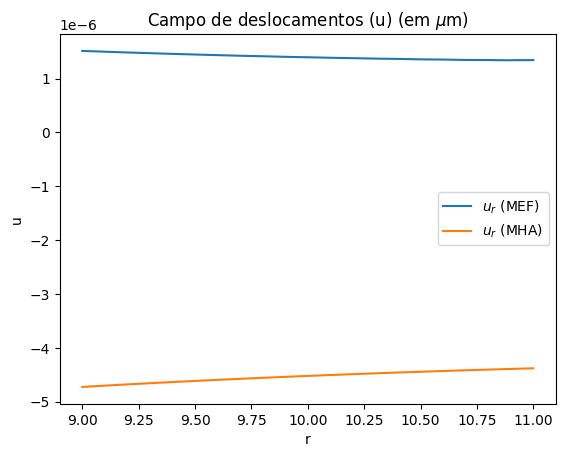

In [ ]:
plt.plot(R, u_MEF, label=r'$u_r$ (MEF)')
plt.plot(R, u_MHA(R), label=r'$u_r$ (MHA)') # As soluções divergem por um fator em torno de 3.25 (com 20 camadas)
plt.title(r'Campo de deslocamentos (u) (em $\mu$m)')
plt.xlabel('r')
plt.ylabel(r'u')
plt.legend()
plt.show()

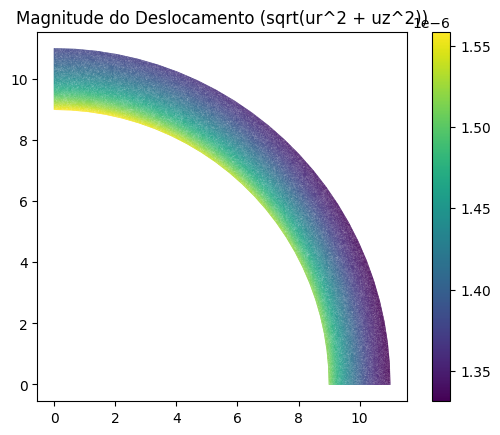

In [ ]:
plt.figure() # Cria uma nova figura
p = plot(u, title="Magnitude do Deslocamento (sqrt(ur^2 + uz^2))")

# Adiciona uma barra de cores para ver a escala
plt.colorbar(p)
plt.show() # Mostra o gráfico

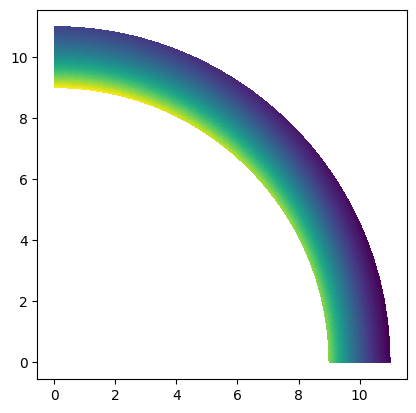

In [ ]:
plt.figure()
plot(100*u, mode="displacement")
plt.show()

## Validações

Como a soluções não estão batendo, vou fazer alguns testes para ver se há alguma diferença

### 1. Matriz de elasticidade

In [ ]:
#-----------------------
# 1. Matriz de elasticidade
#-----------------------

# 1.1. Homogeneização
## Parâmetros Físicos (Apenas um material)
R_int = 9.0
R_ext = 11.0
R_I = 9 + (Re - Ri)/2

# Camada dupla (Ex: Aço e Alumínio)
E1, nu1 = 200e9, 0.30  # Material 1 (Aço)
E2, nu2 = 70e9,  0.33  # Material 2 (Alumínio)

# Frações volumétricas
v1 = np.pi * (R_I**2 - R_int**2) / (np.pi * (R_ext**2 + R_int**2))
v2 = 1 - v1

def effective_coeffs(E_1, E_2, nu_1, nu_2, v1, v2):
  lmbda_1 = (E_1 * nu_1) / ((1 + nu_1) * (1 - 2 * nu_1))
  lmbda_2 = (E_2 * nu_2) / ((1 + nu_2) * (1 - 2 * nu_2))

  mu_1 = E_1 / (2 * (1 + nu_1))
  mu_2 = E_2 / (2 * (1 + nu_2))

  # C11_1 = E_1 / (1 - nu_1**2)
  # C11_2 = E_2 / (1 - nu_2**2)

  # C12_1 = E_1 / (2 * (1 + nu_1))
  # C12_2 = E_2 / (2 * (1 + nu_2))

  C11_1 = lmbda_1 + 2*mu_1
  C11_2 = lmbda_2 + 2*mu_2

  C12_1 = lmbda_1
  C12_2 = lmbda_2

  C11_hat = C11_1 * C11_2 / (C11_2 * v1 + C11_1 * v2)
  C12_hat = C11_hat * (C11_1 / C12_1 * v1 + C11_2 / C12_2 * v2)

  # C11_hat = C11 / (1 + nu)
  # C12_hat = C12 / (1 - 2 * nu)

  return lmbda_1, lmbda_2, mu_1, mu_2, C11_hat, C12_hat

lmbda_1, lmbda_2, mu_1, mu_2, C11_hat, C12_hat = effective_coeffs(E1, E2, nu1, nu2, v1, v2)

# 1.2 Elementos finitos
# --- CLASSE GENÉRICA PARA CAMADAS ESFÉRICAS ---
class PropriedadePeriodica(UserExpression):
    def __init__(self, val1, val2, interfaces, **kwargs):
        super().__init__(**kwargs)
        self.val1 = val1
        self.val2 = val2
        # Otimização: Guarda o quadrado dos raios e garante ordem
        self.R_sq = sorted([r**2 for r in interfaces])

    def eval(self, values, x):
        # Geometria Cilíndrica
        r_sq = x[0]**2 + x[1]**2

        # Descobre o índice da camada
        idx = 0
        found = False
        for i, raio_sq in enumerate(self.R_sq):
            if r_sq <= raio_sq:
                idx = i
                found = True
                break

        if not found:
            idx = len(self.R_sq) # Está além da última interface

        # Lógica de alternância (Par/Ímpar)
        # idx 0 (Núcleo) -> val1
        # idx 1 -> val2
        # idx 2 -> val1 ...
        if idx % 2 == 0:
            values[0] = self.val1
        else:
            values[0] = self.val2

    def value_shape(self):
        return ()

# --- INSTANCIAÇÃO CORRETA ---

# Note que usamos a mesma classe, passando os valores correspondentes
# Ambos recebem a lista COMPLETA 'R_interfaces'

print("Criando expressão para Módulo de Young (E)...")
E_func = PropriedadePeriodica(E1, E2, R_interfaces, degree=degree)

print("Criando expressão para Coef. de Poisson (nu)...")
nu_func = PropriedadePeriodica(nu1, nu2, R_interfaces, degree=degree)

# --- FÓRMULAS DE LAMÉ ---
# O FEniCS vai combinar as duas expressões alternadas automaticamente aqui
lambda_func = (E_func * nu_func) / ((1.0 + nu_func) * (1.0 - 2.0 * nu_func))
mu_func = E_func / (2.0 * (1.0 + nu_func))

Criando expressão para Módulo de Young (E)...
Criando expressão para Coef. de Poisson (nu)...


In [ ]:
R = np.linspace(R_int, R_ext, 2)
lambda_eval = [lambda_viz(r,0) for r in R]
mu_eval = [mu_viz(r,0) for r in R]

In [ ]:
lmbda_1, lmbda_2, mu_1, mu_2

(115384615384.61539, 51083591331.26935, 76923076923.07692, 26315789473.684208)

In [ ]:
lambda_eval, mu_eval

([np.float64(115384615384.61539), np.float64(51083591331.26935)],
 [np.float64(76923076923.07692), np.float64(26315789473.684208)])